<a href="https://colab.research.google.com/github/PhyTorch/Machine-Learning-Lecture/blob/main/Research_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [1]:
import numpy as np

# Insert your values
Name = "Haoyang Jiang" # Replace with your name
CID = 2213534 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Haoyang Jiang [CID: 2213534]

Your challenge code is D


## Problem statement

You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

I am solving the matbench_glass task from Matbench v0.1. This is a composition-only binary classification problem where the input is chemical formula and the target variable `gfa` indicates whether a composition forms a bulk metallic glass. The official benchmark metric is ROC-AUC, and the current best public result on this task is MODNet v0.1.12 (a feed-forward neural network) with mean ROC-AUC 0.9603.

## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [2]:
# Installation of libraries
!pip install matminer==0.9.3 --quiet
!pip install pymatgen --quiet
!pip install torch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.0 MB/s eta 0:00:00


In [3]:
# Import of modules
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from pymatgen.core import Composition

from matminer.datasets import load_dataset
from matminer.datasets.dataset_retrieval import get_all_dataset_info
from matminer.featurizers.composition import ElementProperty, Stoichiometry

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
  roc_auc_score,
  roc_curve,
  accuracy_score,
  balanced_accuracy_score,
  f1_score,
  confusion_matrix,
  ConfusionMatrixDisplay
)

plt.style.use("ggplot")

In [4]:
# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
#info = get_all_dataset_info("matbench_expt_gap")

  # C
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D
info = get_all_dataset_info("matbench_glass")

  # E
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_glass
Description: Matbench v0.1 test dataset for predicting full bulk metallic glass formation ability from chemical formula. Retrieved from "Nonequilibrium Phase Diagrams of Ternary Amorphous Alloys,’ a volume of the Landolt– Börnstein collection. Deduplicated according to composition, ensuring no compositions were reported as both GFA and not GFA (i.e., all reports agreed on the classification designation). For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	gfa: Target variable. Glass forming ability: 1 means glass forming and corresponds to amorphous, 0 means non full glass forming.
Num Entries: 5680
Reference: Y. Kawazoe, T. Masumoto, A.-P. Tsai, J.-Z. Yu, T. Aihara Jr. (1997) Y. Kawazoe, J.-Z. Yu, A.-P. Tsai, T. Masumoto (ed.) SpringerMaterials
Nonequilibrium Phase Diagrams of Ternary Amorphous All

In [5]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_glass")

print(f"The full dataset contains {df.shape[0]} entries.\n")
print("The DataFrame is shown below:")
print(df)

Fetching matbench_glass.json.gz from https://ml.materialsproject.org/projects/matbench_glass.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_glass.json.gz


Fetching https://ml.materialsproject.org/projects/matbench_glass.json.gz in MB: 0.040959999999999996MB [00:00, 55.71MB/s]     

The full dataset contains 5680 entries.

The DataFrame is shown below:
      composition    gfa
0              Al  False
1        Al(NiB)2   True
2     Al10Co21B19   True
3     Al10Co23B17   True
4     Al10Co27B13   True
...           ...    ...
5675        ZrTi9  False
5676      ZrTiSi2   True
5677      ZrTiSi3   True
5678       ZrVCo8   True
5679       ZrVNi2   True

[5680 rows x 2 columns]


In [6]:
# Inspect the dataset
print("Columns in the dataset:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass counts:")
print(df["gfa"].value_counts())

print("\nClass fractions:")
print(df["gfa"].value_counts(normalize=True))

Columns in the dataset:
Index(['composition', 'gfa'], dtype='object')

Missing values:
composition    0
gfa            0
dtype: int64

Class counts:
gfa
True     4035
False    1645
Name: count, dtype: int64

Class fractions:
gfa
True     0.710387
False    0.289613
Name: proportion, dtype: float64


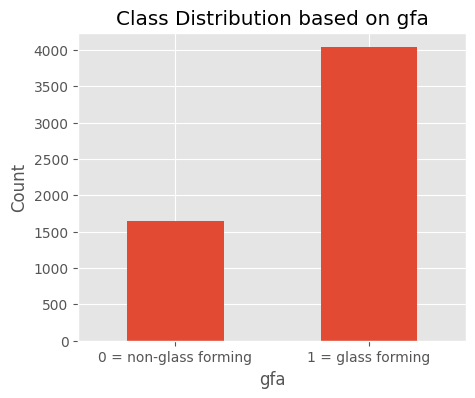

In [7]:
# Plot class balance
plt.figure(figsize=(5, 4))
df["gfa"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["0 = non-glass forming", "1 = glass forming"], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution based on gfa")
plt.show()

In [8]:
# Convert strings to pymatgen Composition objects
df = df.copy()
df["composition_obj"] = df["composition"].apply(Composition)

In [9]:
# Featurise based on composition
ep_feat = ElementProperty.from_preset("magpie")
st_feat = Stoichiometry()

df_feat = ep_feat.featurize_dataframe(
  df,
  col_id="composition_obj",
  ignore_errors=True,
  pbar=True
)

df_feat = st_feat.featurize_dataframe(
  df_feat,
  col_id="composition_obj",
  ignore_errors=True,
  pbar=True
)

print("Featurised DataFrame shape:", df_feat.shape)
df_feat.head()

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/5680 [00:00<?, ?it/s]

Stoichiometry:   0%|          | 0/5680 [00:00<?, ?it/s]

Featurised DataFrame shape: (5680, 141)


,composition,gfa,composition_obj,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,...,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
0,Al,False,(Al),13.0,13.0,0.0,13.00,0.0000,13.0,73.0,...,0.0,225.00,0.0000,225.0,1,1.000000,1.000000,1.000000,1.000000,1.000000
1,Al(NiB)2,True,"(Al, Ni, B)",5.0,28.0,23.0,15.80,9.7600,5.0,61.0,...,59.0,201.40,28.3200,166.0,3,0.600000,0.514256,0.460906,0.441882,0.428730
2,Al10Co21B19,True,"(Al, Co, B)",5.0,27.0,22.0,15.84,9.3744,27.0,58.0,...,59.0,189.56,17.9056,194.0,3,0.600666,0.515463,0.463156,0.445125,0.433375
3,Al10Co23B17,True,"(Al, Co, B)",5.0,27.0,22.0,16.72,9.4576,27.0,58.0,...,59.0,190.68,16.7824,194.0,3,0.605970,0.524924,0.479923,0.467714,0.462202
4,Al10Co27B13,True,"(Al, Co, B)",5.0,27.0,22.0,18.48,9.2016,27.0,58.0,...,59.0,192.92,13.9984,194.0,3,0.631823,0.567782,0.543502,0.540535,0.540039


In [10]:
# Prepare X and y
cols_to_drop = ["composition", "composition_obj", "gfa"]
feature_df = df_feat.drop(columns=cols_to_drop, errors="ignore")

# Keep only numeric columns
feature_df = feature_df.select_dtypes(include=[np.number])

# Replace inf values, then impute missing values
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(feature_df)

y = df_feat["gfa"].astype(np.float32).values

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (5680, 138)
Shape of y: (5680,)


In [11]:
# Train test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=CID,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   # 0.25 of 0.80 gives 0.20 overall
    random_state=CID,
    stratify=y_train_full
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (3408, 138)
X_val shape:   (1136, 138)
X_test shape:  (1136, 138)


In [12]:
# Standardise features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

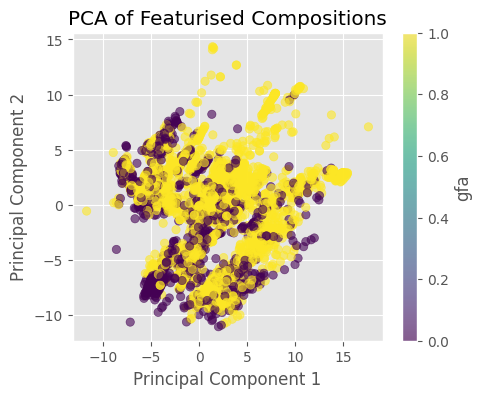

In [13]:
# PCA visualisation of the training features
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(5, 4))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    alpha=0.6
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Featurised Compositions")
plt.colorbar(scatter, label="gfa")
plt.show()

Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

In [14]:
# Build PyTorch DataLoaders
def make_loader(X_array, y_array, batch_size=64, shuffle=False):
  X_tensor = torch.tensor(X_array, dtype=torch.float32)
  y_tensor = torch.tensor(y_array, dtype=torch.float32).view(-1, 1)
  dataset = TensorDataset(X_tensor, y_tensor)
  return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=256, shuffle=False)
test_loader = make_loader(X_test, y_test, batch_size=256, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [15]:
# Define the FFNN model
class FeedForwardNN(nn.Module):
  def __init__(self, input_dim, hidden_dims=[256, 128], dropout=0.2):
    super().__init__()

    layers = []
    prev_dim = input_dim

    for hidden_dim in hidden_dims:
      layers.append(nn.Linear(prev_dim, hidden_dim))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout))
      prev_dim = hidden_dim

    layers.append(nn.Linear(prev_dim, 1))  # single logit output

    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

In [16]:
# Evaluation function
def evaluate_model(model, data_loader, criterion):
  model.eval()

  total_loss = 0.0
  y_true = []
  y_score = []

  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      logits = model(X_batch)
      loss = criterion(logits, y_batch)

      total_loss += loss.item() * len(y_batch)

      probs = torch.sigmoid(logits)
      y_true.extend(y_batch.cpu().numpy().ravel())
      y_score.extend(probs.cpu().numpy().ravel())

  mean_loss = total_loss / len(data_loader.dataset)
  roc_auc = roc_auc_score(y_true, y_score)

  return mean_loss, roc_auc, np.array(y_true), np.array(y_score)

In [22]:
# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=100):

  history = {
    "train_loss": [],
    "val_loss": [],
    "val_roc_auc": []
  }

  best_val_auc = -np.inf
  best_state = None

  for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()
      logits = model(X_batch)
      loss = criterion(logits, y_batch)
      loss.backward()
      optimizer.step()

      running_loss += loss.item() * len(y_batch)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_auc, _, _ = evaluate_model(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_roc_auc"].append(val_auc)

    print(
      f"Epoch {epoch+1:03d} | "
      f"Train Loss: {train_loss:.4f} | "
      f"Val Loss: {val_loss:.4f} | "
      f"Val ROC-AUC: {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
      best_val_auc = val_auc
      best_state = copy.deepcopy(model.state_dict())

  model.load_state_dict(best_state)
  return model, history, best_val_auc

In [23]:
# Positive-class weighting
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos

# For a single binary class
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight.item())

pos_weight: 0.40768277645111084


In [25]:
# Candidate models (Hyperparameters)
candidate_configs = [
  {"hidden_dims": [128, 64], "dropout": 0.10, "lr": 1e-3, "weight_decay": 1e-5},
  {"hidden_dims": [256, 128], "dropout": 0.20, "lr": 1e-3, "weight_decay": 1e-4},
  {"hidden_dims": [256, 128, 64], "dropout": 0.30, "lr": 5e-4, "weight_decay": 1e-4},
]

results = []
best_model = None
best_history = None
best_config = None
best_val_auc = -np.inf

input_dim = X_train.shape[1]

for i, config in enumerate(candidate_configs, start=1):
  print("\n" + "=" * 60)
  print(f"Training candidate model {i}: {config}")

  model = FeedForwardNN(
    input_dim=input_dim,
    hidden_dims=config["hidden_dims"],
    dropout=config["dropout"]
  ).to(device)

  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
  optimizer = optim.Adam(
    model.parameters(),
    lr=config["lr"],
    weight_decay=config["weight_decay"]
  )

  model, history, val_auc = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=100,
  )

  results.append({
    "hidden_dims": config["hidden_dims"],
    "dropout": config["dropout"],
    "lr": config["lr"],
    "weight_decay": config["weight_decay"],
    "best_val_roc_auc": val_auc
  })

  if val_auc > best_val_auc:
    best_val_auc = val_auc
    best_model = model
    best_history = history
    best_config = config

results_df = pd.DataFrame(results).sort_values("best_val_roc_auc", ascending=False)
results_df


Training candidate model 1: {'hidden_dims': [128, 64], 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 1e-05}
Epoch 001 | Train Loss: 0.3464 | Val Loss: 0.2998 | Val ROC-AUC: 0.8249
Epoch 002 | Train Loss: 0.2824 | Val Loss: 0.2697 | Val ROC-AUC: 0.8626
Epoch 003 | Train Loss: 0.2655 | Val Loss: 0.2616 | Val ROC-AUC: 0.8716
Epoch 004 | Train Loss: 0.2570 | Val Loss: 0.2562 | Val ROC-AUC: 0.8766
Epoch 005 | Train Loss: 0.2439 | Val Loss: 0.2502 | Val ROC-AUC: 0.8837
Epoch 006 | Train Loss: 0.2446 | Val Loss: 0.2440 | Val ROC-AUC: 0.8903
Epoch 007 | Train Loss: 0.2335 | Val Loss: 0.2540 | Val ROC-AUC: 0.8781
Epoch 008 | Train Loss: 0.2248 | Val Loss: 0.2432 | Val ROC-AUC: 0.8903
Epoch 009 | Train Loss: 0.2218 | Val Loss: 0.2409 | Val ROC-AUC: 0.8919
Epoch 010 | Train Loss: 0.2148 | Val Loss: 0.2392 | Val ROC-AUC: 0.8939
Epoch 011 | Train Loss: 0.2162 | Val Loss: 0.2411 | Val ROC-AUC: 0.8935
Epoch 012 | Train Loss: 0.2106 | Val Loss: 0.2418 | Val ROC-AUC: 0.8915
Epoch 013 | Train Loss: 0.20

,hidden_dims,dropout,lr,weight_decay,best_val_roc_auc
1,"[256, 128]",0.2,0.0010,0.00010,0.921398
0,"[128, 64]",0.1,0.0010,0.00001,0.921067
2,"[256, 128, 64]",0.3,0.0005,0.00010,0.920155


In [26]:
print("Best configuration:")
print(best_config)
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")

Best configuration:
{'hidden_dims': [256, 128], 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001}
Best validation ROC-AUC: 0.9214


In [27]:
# Test-set evaluation
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

test_loss, test_roc_auc, y_true_test, y_score_test = evaluate_model(
  best_model,
  test_loader,
  criterion
)

# Convert probabilities to class labels using threshold 0.5
y_pred_test = (y_score_test >= 0.5).astype(int)

test_accuracy = accuracy_score(y_true_test, y_pred_test)
test_balanced_accuracy = balanced_accuracy_score(y_true_test, y_pred_test)
test_f1 = f1_score(y_true_test, y_pred_test)

print(f"Test loss:              {test_loss:.4f}")
print(f"Test ROC-AUC:           {test_roc_auc:.4f}")
print(f"Test accuracy:          {test_accuracy:.4f}")
print(f"Test balanced accuracy: {test_balanced_accuracy:.4f}")
print(f"Test F1 score:          {test_f1:.4f}")

Test loss:              0.2499
Test ROC-AUC:           0.9221
Test accuracy:          0.8371
Test balanced accuracy: 0.8449
Test F1 score:          0.8782


Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

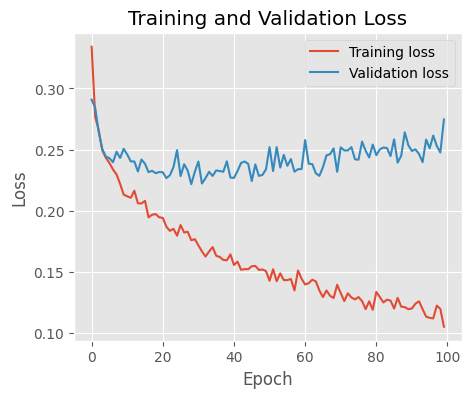

In [28]:
# Plot learning curves
plt.figure(figsize=(5, 4))
plt.plot(best_history["train_loss"], label="Training loss")
plt.plot(best_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

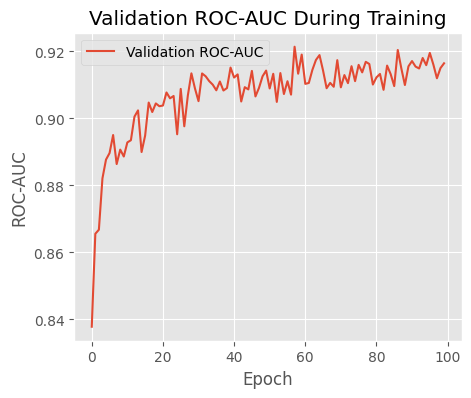

In [29]:
# Validation ROC-AUC during training
plt.figure(figsize=(5, 4))
plt.plot(best_history["val_roc_auc"], label="Validation ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Validation ROC-AUC During Training")
plt.legend()
plt.show()

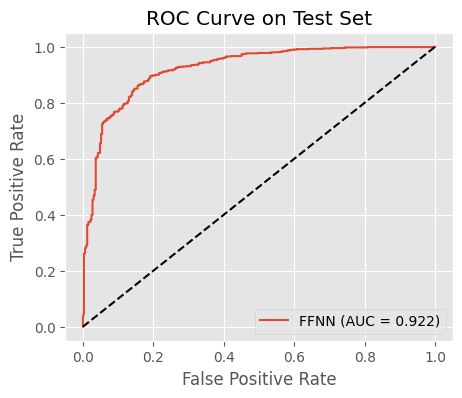

In [30]:
# ROC curve
fpr, tpr, _ = roc_curve(y_true_test, y_score_test)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"FFNN (AUC = {test_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

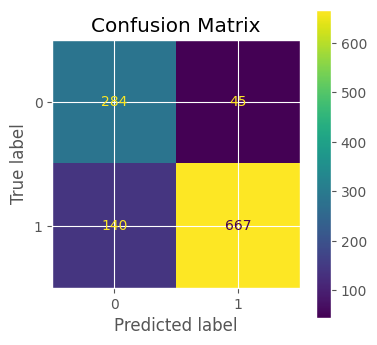

In [31]:
# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
plt.title("Confusion Matrix")
plt.show()

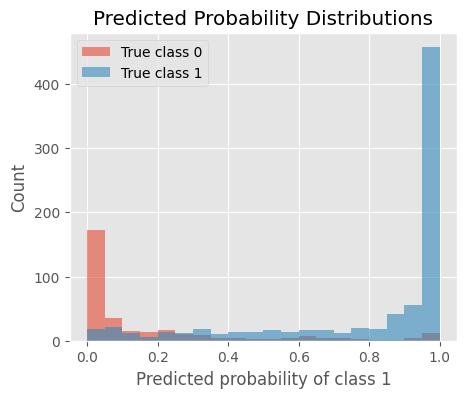

In [32]:
# Probability histogram by true class
plt.figure(figsize=(5, 4))
plt.hist(y_score_test[y_true_test == 0], bins=20, alpha=0.6, label="True class 0")
plt.hist(y_score_test[y_true_test == 1], bins=20, alpha=0.6, label="True class 1")
plt.xlabel("Predicted probability of class 1")
plt.ylabel("Count")
plt.title("Predicted Probability Distributions")
plt.legend()
plt.show()

## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

In [ ]:
# Spare cell




## ☘️ Final word

Good luck building your own model! We hope that you enjoyed the course and exercises. Dive deeper into the aspects that caught your interest. A useful starting point may be the [Resources](https://aronwalsh.github.io/MLforMaterials/Resources.html) page.

Remember that submission is on Blackboard and you should upload both the completed Juypter Notebook (`.ipynb` file), as well as your recorded narrated presentation (maximum 5 minutes; see guides on using [Zoom](https://www.youtube.com/watch?v=H9qhoAIzW3E) or [Powerpoint](https://www.youtube.com/watch?v=Y5dgwwa5XRA) for this purpose).